# 🥥 Análisis de competencia · Aceite de coco en Bolivia

**Proyecto:** coco-analytics — emprendimiento de producción de aceite de coco
**Enfoque:** entender el mercado y la **competencia** (marcas importadas y locales) antes de producir y vender a nivel nacional en Bolivia.
**Fecha:** julio 2026

---

## ¿Qué responde este notebook?

1. **De dónde viene** el aceite de coco en el mundo y **cuánto vale** (contexto global de exportación).
2. **Cómo está distribuido** ese comercio (países exportadores, importadores, precios, empresas).
3. **El mercado boliviano**: cuánto importa Bolivia, de qué países, qué marcas compiten y a qué precio.
4. **Marco legal** para producir y vender aceite de coco en Bolivia (SENASAG, etiquetado, aranceles).
5. **Materia prima local** y **conclusiones estratégicas** para el emprendimiento.

> ⚠️ **Nota de calidad de datos.** Bolivia es un actor muy pequeño en el comercio mundial de aceite de coco, así que sus cifras de importación **no se publican de forma limpia** en los agregadores. Los números de Bolivia provienen de *datos espejo* (lo que los países exportadores declaran haber enviado a Bolivia) y de relevamiento de precios/marcas en retail. **Trátalos como direccionales, no auditados.** Cada dato lleva su fuente en los CSV de `datos/`.


## 1. Preparación del entorno

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Rutas: el notebook vive en analisis/ ; los datos en analisis/datos/ ; el código en src/
BASE = Path.cwd()
if (BASE / "datos").exists():
    ANALISIS = BASE
else:  # por si se ejecuta desde la raíz del repo
    ANALISIS = BASE / "analisis"
DATOS = ANALISIS / "datos"
sys.path.append(str(ANALISIS.parent / "src"))

from estilo import aplicar_estilo, formato_millones, guardar, COCO, PALETA
aplicar_estilo()

def cargar(nombre):
    return pd.read_csv(DATOS / nombre)

print("Entorno listo. Datos en:", DATOS)
print("Archivos:", sorted(p.name for p in DATOS.glob('*.csv')))


Entorno listo. Datos en: /home/user/coco-analytics/analisis/datos
Archivos: ['competencia_marcas_bolivia.csv', 'empresas_exportadoras.csv', 'empresas_importadoras_bolivia.csv', 'exportadores_mundo_2024.csv', 'filipinas_destinos_2024.csv', 'fuentes_oficiales_bolivia.csv', 'importaciones_bolivia_origen.csv', 'importadores_mundo_2024.csv', 'marco_legal_costos.csv', 'precios_bolivia.csv', 'precios_internacionales.csv', 'valor_mundial_por_anio.csv']


## 2. Contexto global — ¿de dónde viene y cuánto vale?

El aceite de coco se clasifica bajo la partida arancelaria **HS 1513** (y sus subpartidas **1513.11** crudo y **1513.19** refinado).

> 🔍 **Detalle técnico importante:** la partida 1513 completa se titula *"aceites de coco (copra), de almendra de palma (palmiste) o de babasú"*. Las bases de datos la etiquetan "Coconut Oil" porque el coco domina la partida a nivel mundial, pero **al analizar un país concreto (como Bolivia) parte del flujo 1513 puede ser aceite de palmiste**, no coco culinario. Para separar con precisión hay que bajar a 8 dígitos NANDINA: **1513.11.00** (coco crudo) y **1513.19.00** (coco refinado).

Es un mercado dominado por el sudeste asiático.

### 2.1 Valor mundial de exportación por año

El comercio mundial de aceite de coco pasó de **~US$ 6,6 mil millones (2023)** a **~US$ 7,95 mil millones (2024)**, un salto de **+20 %**. Clave: ese salto fue **por precio, no por volumen** (ver 2.4).

,anio,valor_exportacion_mundial_usd,fuente,nota
0,2018,5900000000,IndexBox (revenue de mercado),Base distinta a valor de comercio; referencial
1,2023,6610000000,OEC (HS 1513),Valor de comercio (espejo Comtrade)
2,2024,7950000000,OEC (HS 1513),+20.3% interanual; alza impulsada por precio n...


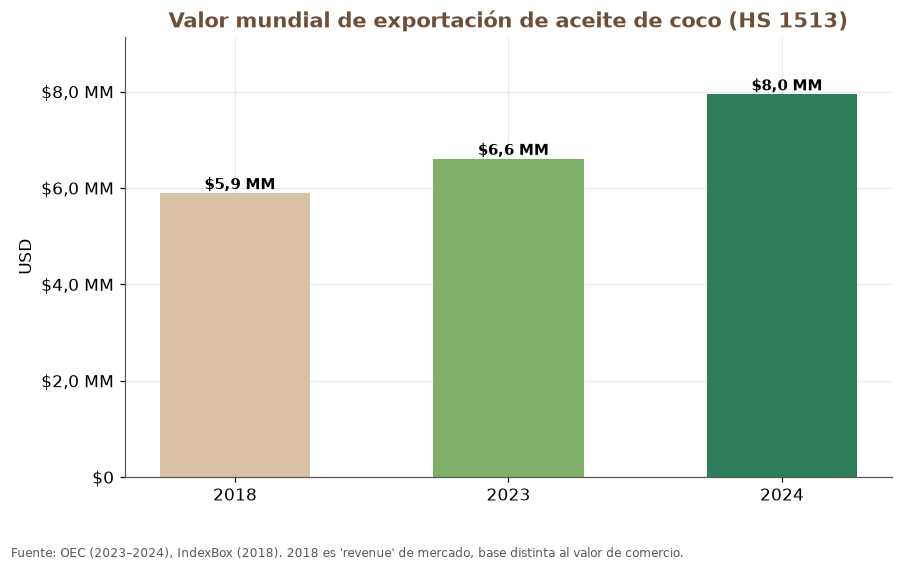

In [2]:
val = cargar("valor_mundial_por_anio.csv")
display(val)

fig, ax = plt.subplots()
ax.bar(val["anio"].astype(str), val["valor_exportacion_mundial_usd"],
       color=[COCO["arena"], COCO["verde_claro"], COCO["verde"]], width=0.55)
for x, y in zip(val["anio"].astype(str), val["valor_exportacion_mundial_usd"]):
    ax.text(x, y, "  " + formato_millones(y), ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_title("Valor mundial de exportación de aceite de coco (HS 1513)")
ax.set_ylabel("USD")
ax.yaxis.set_major_formatter(FuncFormatter(formato_millones))
ax.set_ylim(0, val["valor_exportacion_mundial_usd"].max() * 1.15)
plt.figtext(0.01, -0.03, "Fuente: OEC (2023–2024), IndexBox (2018). 2018 es 'revenue' de mercado, base distinta al valor de comercio.",
            fontsize=8, color=COCO["gris"])
guardar("01_valor_mundial")
plt.show()


### 2.2 ¿Quién exporta? (distribución del mercado)

Tres países concentran cerca del **75 %** del valor exportado. **Indonesia** superó a **Filipinas** como líder en los últimos años. **Países Bajos** aparece alto pero es un **re-exportador** (importa crudo de Asia, refina y redistribuye en la UE), no un productor.

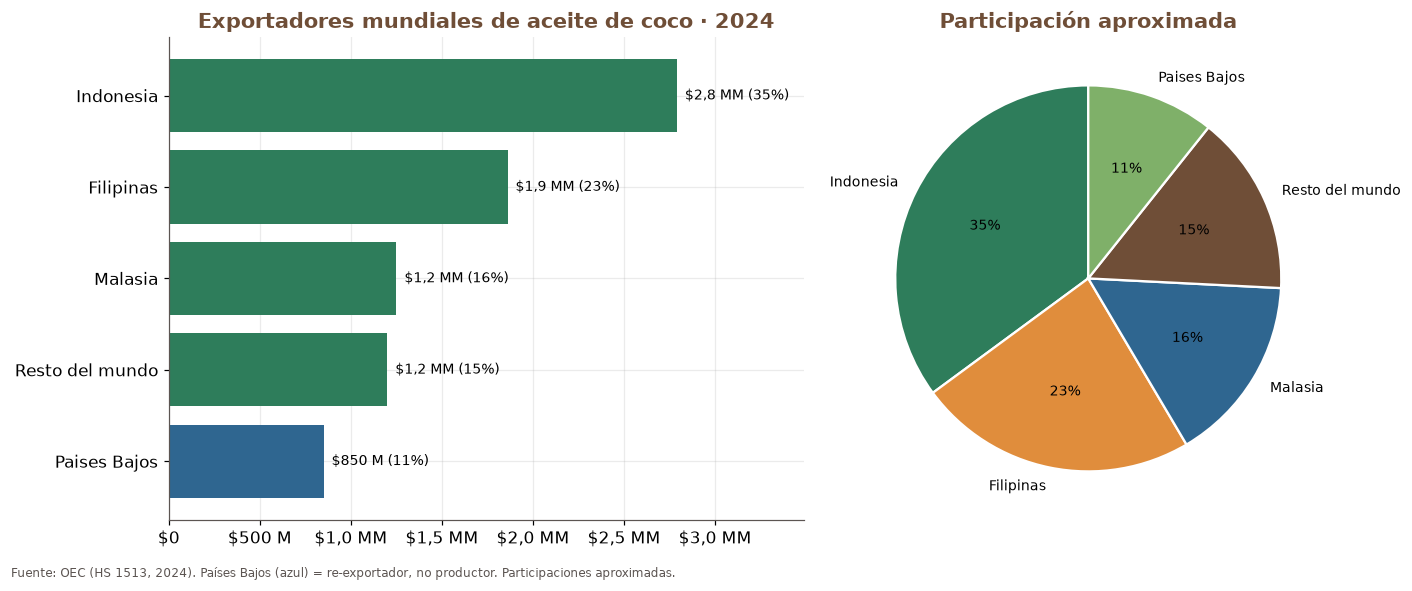

In [3]:
exp = cargar("exportadores_mundo_2024.csv").sort_values("valor_exportacion_usd", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), gridspec_kw={"width_ratios": [1.3, 1]})

# Barras horizontales
colores = [COCO["azul"] if "reexport" in t else COCO["verde"] for t in exp["tipo"]]
axes[0].barh(exp["pais"], exp["valor_exportacion_usd"], color=colores)
for y, (v, p) in enumerate(zip(exp["valor_exportacion_usd"], exp["participacion_pct_aprox"])):
    axes[0].text(v, y, f"  {formato_millones(v)} ({p:.0f}%)", va="center", fontsize=9)
axes[0].set_title("Exportadores mundiales de aceite de coco · 2024")
axes[0].xaxis.set_major_formatter(FuncFormatter(formato_millones))
axes[0].set_xlim(0, exp["valor_exportacion_usd"].max() * 1.25)

# Torta de participación
exp_pie = exp.sort_values("valor_exportacion_usd", ascending=False)
axes[1].pie(exp_pie["participacion_pct_aprox"], labels=exp_pie["pais"], autopct="%1.0f%%",
            colors=PALETA, startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 1.5},
            textprops={"fontsize": 9})
axes[1].set_title("Participación aproximada")

plt.figtext(0.01, -0.02, "Fuente: OEC (HS 1513, 2024). Países Bajos (azul) = re-exportador, no productor. Participaciones aproximadas.",
            fontsize=8, color=COCO["gris"])
plt.tight_layout()
guardar("02_exportadores")
plt.show()


### 2.3 ¿Quién importa?

Estados Unidos y China son los mayores compradores. **Países Bajos** vuelve a aparecer como el **hub de entrada y refinación de la UE**.

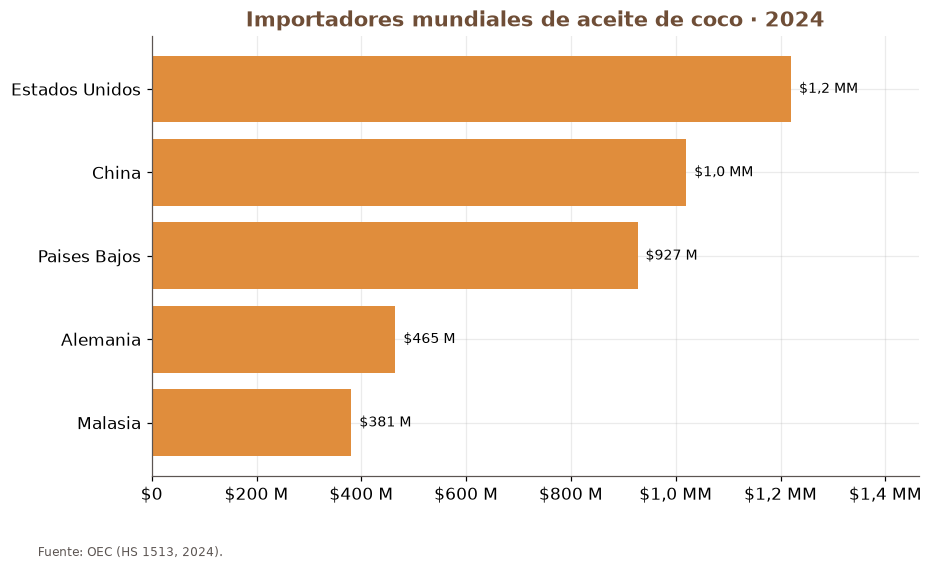

In [4]:
imp = cargar("importadores_mundo_2024.csv").sort_values("valor_importacion_usd", ascending=True)

fig, ax = plt.subplots()
ax.barh(imp["pais"], imp["valor_importacion_usd"], color=COCO["acento"])
for y, v in enumerate(imp["valor_importacion_usd"]):
    ax.text(v, y, "  " + formato_millones(v), va="center", fontsize=9)
ax.set_title("Importadores mundiales de aceite de coco · 2024")
ax.xaxis.set_major_formatter(FuncFormatter(formato_millones))
ax.set_xlim(0, imp["valor_importacion_usd"].max() * 1.2)
plt.figtext(0.01, -0.03, "Fuente: OEC (HS 1513, 2024).", fontsize=8, color=COCO["gris"])
guardar("03_importadores")
plt.show()


### 2.4 Precios internacionales — un salto histórico

El precio del aceite de coco **casi se triplicó** entre mediados de 2024 y fines de 2025, alcanzando un máximo histórico cercano a **US$ 3.000/tonelada**. Causas: sequía por **El Niño** que redujo la cosecha en Filipinas/Indonesia, lluvias de **La Niña** que trabaron la logística, y demanda creciente (alimentos, cosmética, MCT, biocombustible).

**Por qué importa para vos:** encarece el producto importado que hoy compite en Bolivia (bueno para un sustituto local), **pero también encarece la materia prima** (coco/copra) si tuvieras que comprarla a precio internacional.

,periodo,anio,precio_usd_tonelada,base,fuente
0,2018 promedio,2018,1296,FOB Indonesia/Filipinas,Global Trade Mag / IndexBox
1,Jul 2024,2024,1473,CIF Rotterdam,TM Duche
2,2024 promedio,2024,1519,CFR NW Europa,Statista / Banco Mundial
3,Nov 2024,2024,1800,CIF Rotterdam,TM Duche
4,Mediados 2025,2025,2650,CIF Rotterdam,ICC
5,Pico 2025,2025,2990,CIF Rotterdam (maximo historico),ICC
6,Sep 2025,2025,2590,CIF Europa,ICC


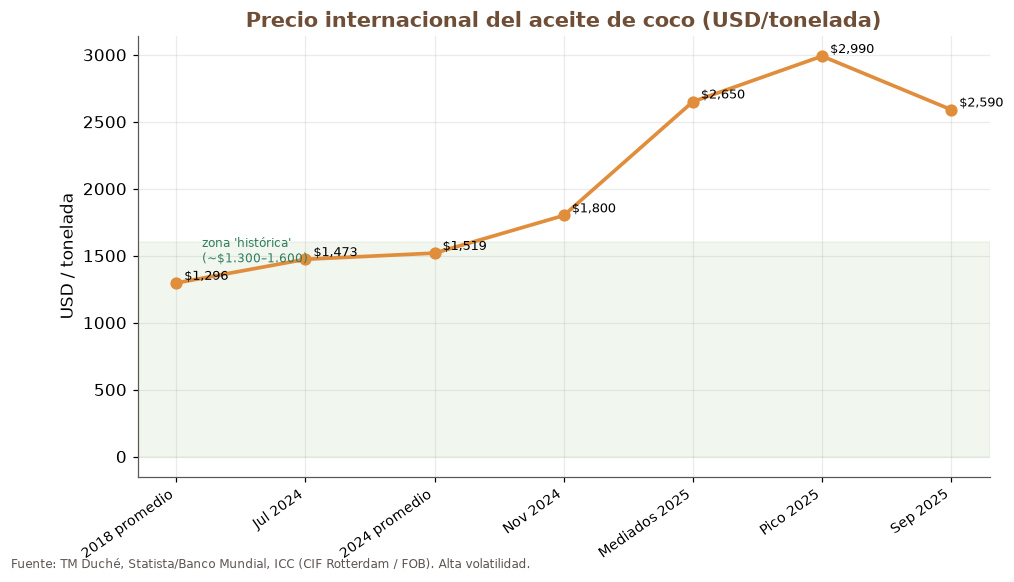

In [5]:
pr = cargar("precios_internacionales.csv")
display(pr)

fig, ax = plt.subplots(figsize=(10, 5.2))
ax.plot(range(len(pr)), pr["precio_usd_tonelada"], marker="o", color=COCO["acento"],
        linewidth=2.4, markersize=7)
for i, (per, v) in enumerate(zip(pr["periodo"], pr["precio_usd_tonelada"])):
    ax.text(i, v, f"  ${v:,.0f}", fontsize=8.5, va="bottom")
ax.set_xticks(range(len(pr)))
ax.set_xticklabels(pr["periodo"], rotation=35, ha="right", fontsize=9)
ax.set_title("Precio internacional del aceite de coco (USD/tonelada)")
ax.set_ylabel("USD / tonelada")
ax.axhspan(0, 1600, color=COCO["verde_claro"], alpha=0.10)
ax.text(0.2, 1450, "zona 'histórica'\n(~$1.300–1.600)", fontsize=8, color=COCO["verde"])
plt.figtext(0.01, -0.05, "Fuente: TM Duché, Statista/Banco Mundial, ICC (CIF Rotterdam / FOB). Alta volatilidad.",
            fontsize=8, color=COCO["gris"])
guardar("04_precios_internacionales")
plt.show()


### 2.5 Principales empresas exportadoras

No existe una tabla pública de cuotas de mercado auditada; los grandes nombres son traders/procesadores globales y productores filipinos.

In [6]:
emp = cargar("empresas_exportadoras.csv")
emp[["empresa", "pais_sede", "rol", "nota"]]


,empresa,pais_sede,rol,nota
0,Wilmar International,Singapur,Trader/procesador,Uno de los mayores traders de aceite de coco y...
1,Cargill,EE.UU. (op. Indonesia),Trader/procesador,PT Cargill Indonesia ~9% de un set de exportac...
2,Franklin Baker Company,Filipinas,Procesador/exportador,Gran procesador de coco filipino
3,Celebes Coconut Corporation,Filipinas,Productor,Crudo/RBD/virgen; posicionamiento organico y F...
4,Primex Coconut Products,Filipinas,Productor,Productor filipino
5,United Coconut Chemicals (Cocochem),Filipinas,Oleoquimica,Derivados quimicos del coco
6,Peter Cremer,Alemania,Procesador oleoquimico,Comprador/procesador
7,P&G Chemicals,EE.UU.,Oleoquimica,Comprador/procesador
8,Marico Ltd,India,FMCG,Marca de consumo (Parachute)
9,Palmtop Sdn Bhd,Malasia,Exportador,~4% de un set de exportaciones rastreado


## 3. 🇧🇴 El mercado boliviano y la competencia

Aquí está el corazón del análisis. Tres hechos clave:

- Bolivia es un **mercado pequeño y de nicho**: no aparece entre los importadores rankeados de OEC. Sus importaciones anuales de aceite de coco rondarían **US$ 0,8–1,5 millones/año** (estimación a partir de datos espejo).
- El aceite de coco en Bolivia es un **producto premium** (virgen/extra virgen, prensado en frío) orientado a salud, belleza y gourmet — **no** es un aceite de cocina masivo (los bolivianos cocinan con soya/girasol a ~Bs 14/L).
- Buena parte de la competencia **ya es local/artesanal** (Becoco, Madre Tierra, Dream Cos), no grandes multinacionales.

### 3.1 ¿De dónde llega el aceite de coco importado a Bolivia?

El suministro es **regional** (re-exportado dentro de Latinoamérica), no directo desde Asia. **Ecuador** es el origen dominante: en 2023 le vendió a Bolivia **~US$ 765 mil** en partida 1513 — Bolivia fue su **5º destino** (~13 % de las exportaciones 1513 de Ecuador). Además hay evidencia de que el flujo **viene creciendo** (dic-2021: +582 % interanual en el mes).

Los demás vecinos aportan poco: Brasil quedó **fuera del top-5** de sus propios destinos en 2023 (o sea, **< US$ 249k** anuales a Bolivia), Perú **< US$ 678k** (2022, fuera de su top-5) y Chile exporta prácticamente **cero**. Bolivia tampoco **exporta** partida 1513 (no aparece en ningún ranking exportador).

> ⚠️ **Matiz palmiste:** Ecuador es un gran productor de palma, así que una parte del flujo 1513 Ecuador→Bolivia podría ser **aceite de palmiste industrial** y no aceite de coco culinario. La separación exacta requiere la partida NANDINA a 8 dígitos (ver §3.5).

,origen,valor_usd,periodo,tipo_dato,fuente,confianza,nota
0,Ecuador,765000,2023,espejo (Ecuador declara exportacion a Bolivia),OEC (Ecuador reporter),media,Bolivia = 5to destino de Ecuador (~13% de sus ...
1,Ecuador,59800,dic-2021,espejo (un solo mes; +582% interanual),OEC (Ecuador reporter),baja,Punto mensual; muestra crecimiento del flujo
2,Brasil,24400,dic-2024,espejo (un solo mes),OEC (Brazil reporter),baja,Bolivia 5to destino de Brasil ese mes
3,Brasil,249000,2023,cota superior (Bolivia fuera del top-5 de Brasil),OEC (Brazil reporter),baja,Valor anual < US$249k (el 5to destino fue Alem...
4,Peru,678000,2022,cota superior (Bolivia fuera del top-5 de Peru),OEC (Peru reporter),baja,Valor anual < US$678k
5,Chile,0,2024,~0 (exportaciones de Chile casi nulas),OEC (Chile reporter),media,Chile no es proveedor de Bolivia


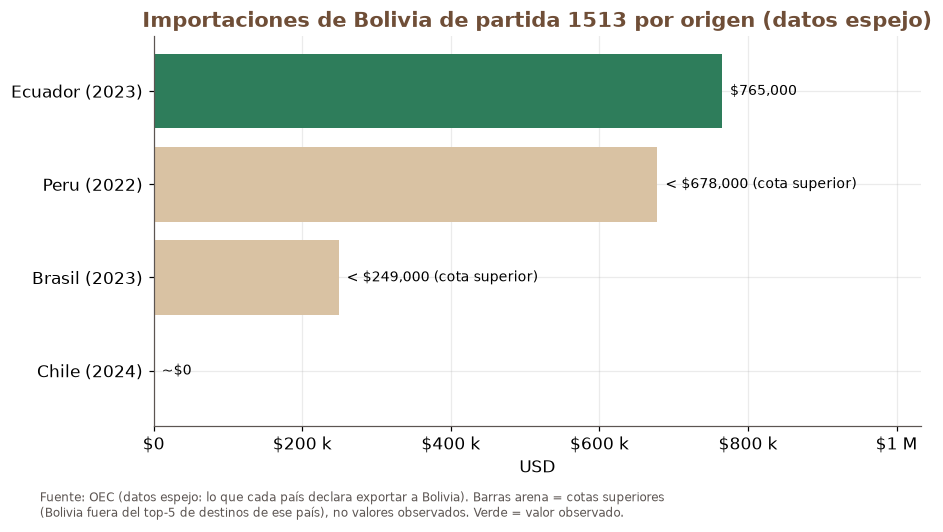

Lectura: Ecuador (~$765k, 2023) es el único proveedor relevante confirmado. Brasil y Perú quedan
acotados por debajo de $249k y $678k/año respectivamente; Chile ~0. Bolivia no exporta 1513.


In [7]:
bo = cargar("importaciones_bolivia_origen.csv")
display(bo)

# Graficamos solo los flujos anuales o acotados (excluimos puntos mensuales sueltos)
anuales = bo[bo["periodo"].isin(["2023", "2022", "2024"])].copy()
anuales["etiqueta"] = anuales["origen"] + " (" + anuales["periodo"].astype(str) + ")"
anuales = anuales.sort_values("valor_usd")

fig, ax = plt.subplots(figsize=(9, 4.6))
es_cota = anuales["tipo_dato"].str.contains("cota|~0")
colores = [COCO["arena"] if c else COCO["verde"] for c in es_cota]
ax.barh(anuales["etiqueta"], anuales["valor_usd"], color=colores)
for y, (v, c) in enumerate(zip(anuales["valor_usd"], es_cota)):
    etiqueta = f"  < ${v:,.0f} (cota superior)" if c and v > 0 else (f"  ~$0" if v == 0 else f"  ${v:,.0f}")
    ax.text(max(v, 1), y, etiqueta, va="center", fontsize=9)
ax.set_title("Importaciones de Bolivia de partida 1513 por origen (datos espejo)")
ax.set_xlabel("USD")
ax.xaxis.set_major_formatter(FuncFormatter(formato_millones))
ax.set_xlim(0, anuales["valor_usd"].max() * 1.35)
plt.figtext(0.01, -0.07, "Fuente: OEC (datos espejo: lo que cada país declara exportar a Bolivia). Barras arena = cotas superiores\n(Bolivia fuera del top-5 de destinos de ese país), no valores observados. Verde = valor observado.",
            fontsize=8, color=COCO["gris"])
guardar("05_origen_bolivia")
plt.show()

print("Lectura: Ecuador (~$765k, 2023) es el único proveedor relevante confirmado. Brasil y Perú quedan")
print("acotados por debajo de $249k y $678k/año respectivamente; Chile ~0. Bolivia no exporta 1513.")


### 3.2 ¿Quién importa? Las empresas registradas en aduana

Los registros aduaneros (agregados por Volza para HS 1513) muestran a los **importadores directos** — este es el dato de "principales empresas" del lado boliviano:

| Empresa | Envíos registrados | Participación |
|---|---|---|
| **DREAMCO SRL** | 11 | ~25 % |
| **ANTORVA S.R.L** | 5 | ~11 % |
| **HANSA LTDA** | 4 | ~9 % |

💡 **Hallazgo clave:** DREAMCO SRL es muy probablemente la misma empresa detrás de la marca **"Dream Cos"** (dreamcosrl.com) que aparece en nuestra tabla de competencia como marca "local". Es decir: **el principal competidor "local" en realidad importa** (a granel o envasado) en vez de producir con coco boliviano. Eso deja el posicionamiento **"producido en Bolivia con coco boliviano" prácticamente vacante** — nadie grande lo ocupa. *(Verificar la identidad societaria antes de afirmarlo públicamente.)*

,empresa,envios_registrados,participacion_pct,nota,fuente
0,DREAMCO SRL,11,25,Mayor importador de coco/aceite de coco (HS 15...,Volza (HS 1513 buyers Bolivia)
1,ANTORVA S.R.L,5,11,Segundo importador registrado,Volza (HS 1513 buyers Bolivia)
2,HANSA LTDA,4,9,Tercer importador registrado; grupo importador...,Volza (HS 1513 buyers Bolivia)
3,Otros,24,55,Resto de importadores menores (estimado residual),Volza (residual estimado)


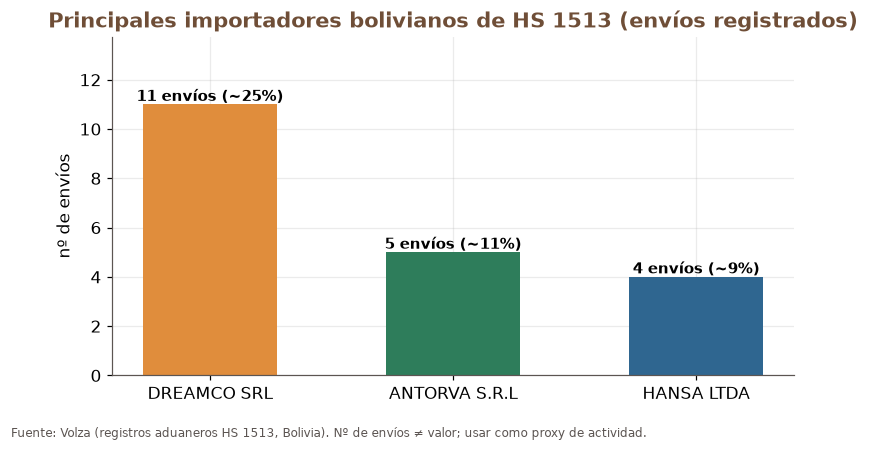

In [8]:
ei = cargar("empresas_importadoras_bolivia.csv")
display(ei)

con_datos = ei[ei["empresa"] != "Otros"]
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(con_datos["empresa"], con_datos["envios_registrados"],
       color=[COCO["acento"], COCO["verde"], COCO["azul"]], width=0.55)
for x, (v, p) in enumerate(zip(con_datos["envios_registrados"], con_datos["participacion_pct"])):
    ax.text(x, v, f"{v} envíos (~{p}%)", ha="center", va="bottom", fontsize=9.5, fontweight="bold")
ax.set_title("Principales importadores bolivianos de HS 1513 (envíos registrados)")
ax.set_ylabel("nº de envíos")
ax.set_ylim(0, con_datos["envios_registrados"].max() * 1.25)
plt.figtext(0.01, -0.03, "Fuente: Volza (registros aduaneros HS 1513, Bolivia). Nº de envíos ≠ valor; usar como proxy de actividad.",
            fontsize=8, color=COCO["gris"])
guardar("05b_importadores_empresas")
plt.show()


### 3.3 La competencia: marcas en el mercado boliviano

El nicho premium-VCO está servido hoy sobre todo por **pequeños jugadores nacionales/artesanales**. Los supermercados grandes (Ketal, Hipermaxi, Fidalga) lo llevan de forma esporádica. No se detectó una gran marca importada dominando las góndolas.

,marca,origen,tipo_producto,presentaciones,precio_bs_rango,canal
0,Becoco,Bolivia (local),Extra virgen prensado en frio sin refinar,200 ml / 720 ml,55-140,Tiendas naturales / e-commerce / redes
1,Madre Tierra,Bolivia (local),Extra virgen organico certificado prensado en ...,frascos pequenos,s/d,Tiendas naturales / Amazon
2,Dream Cos,Bolivia (local),Extra virgen,200 ml,s/d,E-commerce
3,Viasana,Bolivia (retailer),Extra virgen premium,720 ml,s/d,Tienda de salud
4,Natural Farma,Bolivia (retailer),Aceite de coco (salud),s/d,s/d,Farmacia natural
5,Organic Natural Shop,Bolivia (retailer),Aceite de coco,370 ml,s/d,E-commerce
6,Artesanales varios,Bolivia (local),Prensado en frio virgen,200 ml+,24-200,Ferias / redes / evisos


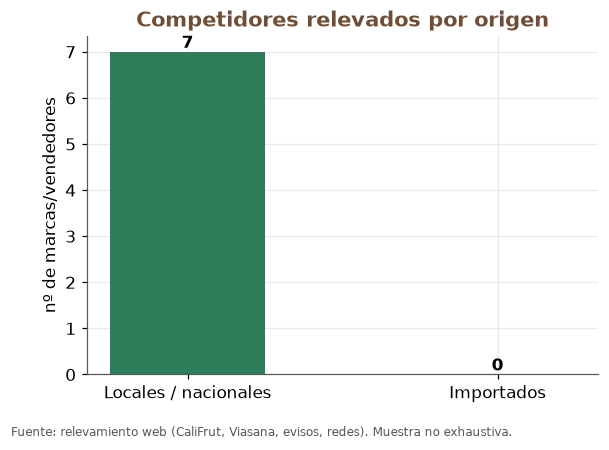

In [9]:
comp = cargar("competencia_marcas_bolivia.csv")
display(comp[["marca", "origen", "tipo_producto", "presentaciones", "precio_bs_rango", "canal"]])

# Cuántos competidores son locales vs importados
loc = comp["origen"].str.contains("Bolivia", case=False)
resumen = pd.Series({"Locales / nacionales": loc.sum(), "Importados": (~loc).sum()})
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(resumen.index, resumen.values, color=[COCO["verde"], COCO["marron"]], width=0.5)
for x, v in zip(resumen.index, resumen.values):
    ax.text(x, v, str(v), ha="center", va="bottom", fontweight="bold")
ax.set_title("Competidores relevados por origen")
ax.set_ylabel("nº de marcas/vendedores")
plt.figtext(0.01, -0.03, "Fuente: relevamiento web (CaliFrut, Viasana, evisos, redes). Muestra no exhaustiva.",
            fontsize=8, color=COCO["gris"])
guardar("06_competencia_origen")
plt.show()


### 3.4 Precios en Bolivia — el aceite de coco es un producto premium

El aceite de coco se vende **muy por encima** del aceite de cocina común. Un litro de aceite de coco a granel (~Bs 200) cuesta **~14 veces** un litro de aceite de soya FINO (~Bs 14).

Esto define el posicionamiento: **no competís contra el aceite de cocina barato**, competís en el segmento salud/belleza/gourmet.

,segmento,precio_bs,unidad,equivalente_bs_100ml,fuente
0,Aceite de soya FINO (referencia cocina),14,por litro,1.4,Mercado local
1,Aceite de coco mayorista (Santa Cruz/El Alto),60.35-73.77,por kg,6-7.4,Selina Wamucii 2025-26
2,Aceite de coco retail a granel,200,por litro,20,Listados de mercado
3,Becoco 720 ml extra virgen,140,por frasco 720 ml,19.4,CaliFrut
4,Becoco 200 ml extra virgen,55,por frasco 200 ml,27.5,CaliFrut
5,Artesanal frasco pequeno (entrada),30-40,por frasco pequeno,15-20,Listados Santa Cruz


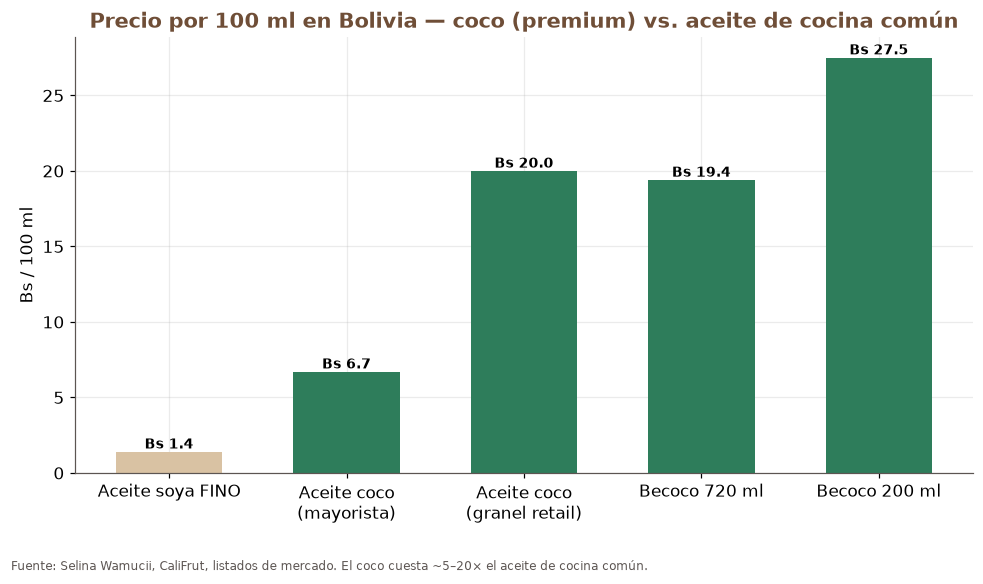

In [10]:
prb = cargar("precios_bolivia.csv")
display(prb)

# Comparativa por 100 ml (donde hay valor numérico simple)
comparables = pd.DataFrame({
    "producto": ["Aceite soya FINO", "Aceite coco\n(mayorista)", "Aceite coco\n(granel retail)",
                 "Becoco 720 ml", "Becoco 200 ml"],
    "bs_100ml": [1.4, 6.7, 20, 19.4, 27.5],
    "tipo": ["cocina común", "coco", "coco", "coco", "coco"],
})
fig, ax = plt.subplots(figsize=(9, 5))
colores = [COCO["arena"] if t == "cocina común" else COCO["verde"] for t in comparables["tipo"]]
ax.bar(comparables["producto"], comparables["bs_100ml"], color=colores, width=0.6)
for x, v in zip(comparables["producto"], comparables["bs_100ml"]):
    ax.text(x, v, f"Bs {v}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_title("Precio por 100 ml en Bolivia — coco (premium) vs. aceite de cocina común")
ax.set_ylabel("Bs / 100 ml")
plt.figtext(0.01, -0.05, "Fuente: Selina Wamucii, CaliFrut, listados de mercado. El coco cuesta ~5–20× el aceite de cocina común.",
            fontsize=8, color=COCO["gris"])
plt.tight_layout()
guardar("07_precios_bolivia")
plt.show()


### 3.5 📥 La serie oficial del INE — cómo obtenerla e integrarla

**Sí, los datos oficiales existen** — el INE los publica — pero requieren consulta interactiva o descarga manual (no son accesibles por API desde este entorno). Fuentes oficiales verificadas:

| Fuente | Qué tiene | URL |
|---|---|---|
| **INE — Sistema COMEX** | Consulta por partida NANDINA: valor CIF (US$) y kg, por año y país de origen | http://web3.ine.gob.bo:8082/comex/Main |
| **INE — Importaciones** | Cuadros y series descargables (Excel) | https://www.ine.gob.bo/index.php/estadisticas-economicas/comercio-exterior/importacion/ |
| **Min. Des. Productivo — COMEX** | Portal interactivo, actualización mensual | https://data-bolivia.produccion.gob.bo/comex/ |
| **IBCE — Cifras 2024/2025 (PDF)** | Anuarios del comercio exterior boliviano | https://ibce.org.bo/publicaciones-ibcecifras.php |
| **TrendEconomy — Bolivia 1513** | Serie anual 2012–2023 (base Comtrade) | https://trendeconomy.com/data/h2/Bolivia/1513 |

**Receta paso a paso (sistema COMEX del INE):**
1. Entrá a `http://web3.ine.gob.bo:8082/comex/Main`.
2. Elegí **Importaciones**, período **2015–2025** (anual).
3. Buscá las partidas NANDINA **`1513.11.00`** (aceite de coco crudo) y **`1513.19.00`** (refinado) — usá las de 8 dígitos para excluir el palmiste (`1513.21` / `1513.29`).
4. Pedí la apertura **por país de origen** y exportá a Excel/CSV.
5. Guardá el archivo como `data/raw/ine_comex_1513.csv` con columnas: `anio, nandina, origen, valor_cif_usd, kg`.
6. Volvé a ejecutar la celda de abajo: detecta el archivo y genera automáticamente la serie oficial.

El listado completo de fuentes (incluyendo las de pago como Veritrade/Nosis) está en `datos/fuentes_oficiales_bolivia.csv`.

In [11]:
fo = cargar("fuentes_oficiales_bolivia.csv")
display(fo[["fuente", "contenido", "acceso"]])

# --- Integración automática de la serie oficial del INE (si ya la descargaste) ---
RUTA_INE = ANALISIS.parent / "data" / "raw" / "ine_comex_1513.csv"
if RUTA_INE.exists():
    ine = pd.read_csv(RUTA_INE)
    print(f"✅ Serie oficial del INE encontrada: {len(ine)} filas")
    serie = ine.groupby("anio")["valor_cif_usd"].sum()
    fig, ax = plt.subplots()
    ax.bar(serie.index.astype(str), serie.values, color=COCO["verde"])
    ax.set_title("Importaciones de Bolivia — aceite de coco (NANDINA 1513.11/1513.19, INE)")
    ax.set_ylabel("USD CIF")
    ax.yaxis.set_major_formatter(FuncFormatter(formato_millones))
    guardar("08_serie_oficial_ine")
    plt.show()
    display(ine.groupby(["anio", "origen"])["valor_cif_usd"].sum().unstack(fill_value=0))
else:
    print("ℹ️  Serie oficial del INE aún no descargada.")
    print(f"   Cuando la tengas, guardala en: {RUTA_INE}")
    print("   con columnas: anio, nandina, origen, valor_cif_usd, kg — y re-ejecutá esta celda.")


,fuente,contenido,acceso
0,INE - Sistema de consulta COMEX,Consulta interactiva por partida NANDINA (1513...,Gratuito en linea (la fuente que pediste revisar)
1,INE - Estadisticas de importacion,Series y cuadros de importaciones; indicadores...,Gratuito (descargas Excel)
2,Min. Desarrollo Productivo - COMEX,Portal interactivo de comercio exterior actual...,Gratuito en linea
3,SIIP - Ranking de productos,Ranking de importaciones/exportaciones por pro...,Gratuito en linea
4,IBCE - Estadisticas,Hub de estadisticas de comercio exterior boliv...,Gratuito / consultas a gtecnica@ibce.org.bo
5,IBCE - Cifras 2024 (PDF),Anuario del comercio exterior boliviano 2024,Gratuito (PDF)
6,IBCE - Cifras 2025 (PDF),Anuario del comercio exterior boliviano 2025,Gratuito (PDF)
7,OEC - Aceite de coco reporter Bolivia,Pagina bilateral HS 1513 con Bolivia como repo...,Gratuito en linea
8,TrendEconomy - Bolivia 1513,Serie anual 2012-2023 de importaciones/exporta...,Gratuito en linea
9,Veritrade - Bolivia 151311,Transacciones detalladas por importador (CIF),De pago (suscripcion)


ℹ️  Serie oficial del INE aún no descargada.
   Cuando la tengas, guardala en: /home/user/coco-analytics/data/raw/ine_comex_1513.csv
   con columnas: anio, nandina, origen, valor_cif_usd, kg — y re-ejecutá esta celda.


## 4. Marco legal y regulatorio en Bolivia

Para **producir y vender** aceite de coco (alimento) en Bolivia necesitás cumplir tres frentes: **registro sanitario (SENASAG)**, **etiquetado (IBNORCA)** y la carga tributaria de importación (relevante para entender el costo de tu competencia importada).

In [12]:
leg = cargar("marco_legal_costos.csv")
leg


,concepto,detalle,valor,vigencia,fuente
0,Registro sanitario SENASAG - Industrial,Fabricacion/envasado alimentos,1600 Bs,2 anios,SENASAG
1,Registro sanitario SENASAG - Semi-industrial,Fabricacion/envasado alimentos,1000 Bs,2 anios,SENASAG
2,Registro sanitario SENASAG - Artesanal,Fabricacion/envasado alimentos,500 Bs,2 anios,SENASAG
3,Etiquetado,Norma NB 314001:2015 (IBNORCA),cumplimiento obligatorio,vigente,IBNORCA
4,Gravamen Arancelario importacion HS 1513,Estructura 0/5/10/15/20/30/40; probable 10% (c...,~10% (a confirmar),2026,AAI-2026 / SIIP
5,IVA importacion,Impuesto al valor agregado efectivo,14.94%,vigente,Bolivia Impuestos
6,ICE,Impuesto consumos especificos,no aplica al aceite de coco,vigente,Bolivia Impuestos
7,Arancel Cero DS 5516,0% GA para maquinaria/equipo agroalimentario,0% hasta 31-dic-2026,2026,DS 5516


### Detalle de los requisitos

**a) Registro sanitario — SENASAG** (obligatorio para fabricar/envasar/vender alimentos)
Norma: *Requisitos sanitarios para la fabricación, almacenamiento, envasado y transporte de alimentos y bebidas para consumo humano.*
Documentos típicos (procesadora): carta de solicitud, copia del **NIT**, flujograma de proceso por producto, croquis de distribución de ambientes y de ubicación de la planta, análisis del producto. SENASAG hace **visita a planta** y toma muestras de producto y agua para análisis microbiológico (a cargo del solicitante, en laboratorio autorizado).
**Costos (registro por 2 años):** Industrial **Bs 1.600** · Semi-industrial **Bs 1.000** · Artesanal **Bs 500**.

**b) Etiquetado — IBNORCA**
**NB 314001:2015** — *Etiquetado de alimentos preenvasados* (rige productos nacionales e importados). SENASAG además aprueba el **modelo de etiqueta** dentro del registro.
Conviene además comprar la **Norma Boliviana (NB) de aceites y grasas comestibles** para fijar la especificación técnica del producto.

**c) Impuestos y aranceles (contexto de tu competencia importada)**
- **Gravamen Arancelario (GA):** estructura 0/5/10/15/20/30/40 %. Bienes de consumo suelen caer en **~10 %** — *confirmar el valor exacto para 1513.11 / 1513.19 en el Arancel Aduanero de Importaciones 2026 (AAI-2026) o el buscador SIIP.*
- **IVA importación:** efectivo **14,94 %**.
- **ICE:** el aceite de coco **no** paga (no es consumo específico/suntuario).
- 🎯 **Arancel Cero (DS 5516, ene-2026):** **0 % de GA hasta el 31-dic-2026** para **maquinaria y equipo** de la industria agroalimentaria. **Muy relevante para vos:** podrías importar tu prensa/embotelladora con arancel cero este año.

> El producto importado paga GA (~10 %) + IVA (14,94 %) + flete regional. Ese sobrecosto es exactamente la brecha que un productor local puede aprovechar — **si** consigue materia prima competitiva.


## 5. Materia prima local — ¿hay coco en Bolivia?

**Sí, pero a escala modesta.** El coco (*Cocos nucifera*) se cultiva en los llanos tropicales:

- **Santa Cruz** (San Juan, Warnes, Buena Vista, San Carlos) — zona productora principal.
- **Chapare (trópico de Cochabamba)**, **Beni** y **Pando** — zonas aptas.
- Introducido al Beni desde Brasil hacia **1553**.

⚠️ Las cifras oficiales son escasas e inconsistentes (una fuente cita "27,5 ha / 8.250 t" en San Juan, cifra internamente contradictoria — tomar con cautela). La producción local se orienta hoy a **fruta fresca / agua de coco**, no a extracción de aceite.

**Implicancia:** existe coco local pero en volúmenes pequeños. Una operación de aceite necesitaría **asegurar/agregar suministro** de nuez o copra (Santa Cruz/Beni/Chapare); de lo contrario dependería del mismo insumo importado que la competencia, **erosionando la ventaja "local"**.

## 6. Conclusiones y recomendaciones estratégicas

### El panorama
| Dimensión | Hallazgo |
|---|---|
| **Tamaño del mercado BO** | Pequeño/nicho (~US$ 0,8–1,5 M/año importados; Ecuador solo = US$ 765k en 2023). Producto premium, no masivo. |
| **Competencia** | **Pequeños jugadores locales** (Becoco, Madre Tierra) + **importadores directos**: DREAMCO SRL (~25 % de envíos), ANTORVA, HANSA. Sin gran marca dominante. |
| **Origen importado** | **Ecuador** dominante y creciente; Brasil/Perú marginales (acotados); Chile ~0. Ojo: parte del flujo 1513 puede ser **palmiste**, no coco. |
| **Precio** | Premium: ~Bs 15–28 / 100 ml, **5–20×** el aceite de cocina común. |
| **Contexto global** | Precios en **máximos históricos** (~US$ 3.000/t): encarece la importación (oportunidad) y la materia prima (riesgo). |
| **Legal** | Barrera de entrada **baja y clara**: registro SENASAG (Bs 500–1.600) + etiquetado NB 314001. |
| **Regalo regulatorio 2026** | **DS 5516**: importá tu prensa con **0 % de arancel** hasta dic-2026. |

### Recomendaciones
1. **Posicionate en el nicho premium/salud-belleza**, no en cocina masiva. Ahí ya está el precio y el margen.
2. **Diferenciación "producido en Bolivia con coco boliviano"**: el hallazgo DREAMCO sugiere que el principal competidor "local" **importa** — ese posicionamiento está prácticamente **vacante**.
3. **Asegurá la materia prima local primero** (Santa Cruz/Chapare/Beni). Es el cuello de botella y la única forma de sostener la ventaja de costo/relato.
4. **Aprovechá el DS 5516 este año** para importar equipo con arancel cero.
5. **Registro SENASAG desde el arranque** (empezá como *artesanal*, Bs 500/2 años) — es barato y es requisito de góndola.
6. **Bajá la serie oficial del INE** (sistema COMEX, receta en §3.5): NANDINA 1513.11.00/1513.19.00 por año y origen — la celda de §3.5 la integra automáticamente al notebook. Confirmá también el GA exacto en AAI-2026 y la identidad DREAMCO SRL ↔ marca Dream Cos.

---

### Próximos análisis sugeridos (roadmap del repo)
- `02_costos_produccion.ipynb` — costo de producción, punto de equilibrio vs. precio de góndola.
- `03_proveedores_materia_prima.ipynb` — mapa de proveedores de coco/copra en Santa Cruz/Chapare/Beni.
- Relevamiento propio de precios de góndola (Ketal/Hipermaxi/Fidalga + e-commerce) para una base de competencia más fina.

> **Fuentes:** todos los datos y sus fuentes están en `analisis/datos/*.csv`. Las cifras de Bolivia son direccionales (mercado pequeño, datos espejo). Ver notas de incertidumbre en cada sección.
